# Temporal Aggregation of EMIT Mineralogy vs. Ground Alunite Geochemistry
## Southern Pine Valley area, southern Wah Wah Range, Beaver County, Utah (Utah Geological Survey AOI)

Tutorial 1 of 2 for the SEG critical-minerals session.

| | |
|---|---|
| This notebook (1) | Aggregates the EMIT L2B_MIN mineralogy product over many dates, then checks the result against UGS surface geochemistry in the `Alunite_zoom` window. Spaceborne only. |
| Companion notebook (2) | `02_white_mica_absorption_centers.ipynb`: identifies white micas with EMIT and compares Al-OH absorption centers between EMIT and AVIRIS-5 reflectance over the White Mica AOI, Wah Wah Range. |

### The problem this notebook solves

A single EMIT scene is one instantaneous look at the surface. Its Tetracorder mineral
identifications are affected by things that have nothing to do with the geology: illumination
geometry on that pass, thin cirrus, residual atmospheric correction error, seasonal dry
vegetation, sensor noise on that particular detector column. So a mineral called in one scene
and missed in the next reports on the observation, not necessarily on the
rock.

Temporal aggregation addresses this. EMIT revisits opportunistically from the ISS, and since
mid-2022 it has built up repeat coverage of most of the mid-latitudes. If we classify every clear
scene over an area and ask, per pixel, "in how many of its valid observations was this pixel
called alunite?", then the scene-specific noise averages down and what survives is the
persistent, mappable mineralogy. That persistence raster is a stronger exploration product
than any single scene, and it is also a quantity (a fraction from 0 to 1) rather than a label,
which is what makes it comparable with a continuous ground measurement.

That ground measurement is what makes this AOI valuable: the Utah Geological Survey has
138 surface samples inside the AOI with major-oxide chemistry, and therefore two independent
stoichiometric estimates of alunite abundance: one from K₂O and one from SO₃. Section 5 brings
those samples together with the aggregate over the same ground, and screens them first, because
alunite carries both potassium and sulfate and neither estimate is reliable without the other.

### Geologic setting: a lithophile critical-metal system in evolved rhyolite

The Southern Pine Valley AOI (southern Wah Wah Range, Beaver County, UT ~ 38.12° N, 113.61° W)
sits on the Pioche mineral belt / Blue Ribbon lineament. The AOI exposes Cambrian through
Devonian carbonates, the Oligocene Needles Range Group ash-flow tuffs, and the Miocene Blawn
Formation rhyolites, and it is the Blawn Formation that carries the critical-metal story.
These are highly-evolved, A-type rhyolites (the ~22.1 Ma Red Beryl Rhyolite and ~18.3 Ma Tetons
Rhyolite; Barkoff, 2022): textbook lithophile / critical-metal magmas that concentrate Be, Li,
Mo, Sn, W, REE, U and F, carry accessory fluorite plus REE phases (cerianite-Ce, allanite,
monazite, xenotime), and are named for their red beryl (bixbite). Historic work
(Lindsey & Osmonson, 1978, USGS OFR 78-114) reported anomalous U, Sn (cassiterite up to
~3,000 ppm), Mo (up to ~150 ppm), Be, and Li (up to ~230 ppm), and notably analysed for gold
and found none at surface. This is a lithophile suite in evolved felsic rock, comparable to the
Spor Mountain, UT beryllium belt and the Climax, CO Mo system, not a gold–silver epithermal
district.

### The alteration system: a spectrally mappable pH gradient

The reason spectroscopy works here is the alteration zonation, which is a map of the mineralizing
fluid's pH (Lindsey & Osmonson, 1978):

- an acidic, advanced-argillic cap (alunite + kaolinite + iron oxide + silicified breccia,
  developed in the rhyolites), the classic alunite lithocap;
- grading into near-neutral to alkaline alteration (montmorillonite + illite + fluorite)
  around intrusive topaz rhyolite (past uranium + fluorspar production at the Staats mine).

Alunite `KAl3(SO4)2(OH)6` marks the acidic core, and it is what this notebook maps: a broad
Al-OH absorption at ~2.16–2.17 µm (with a secondary feature near 2.32 µm) that EMIT's Tetracorder
retrieval keys on. The white-mica halo around that core is the subject of notebook 2.

> References (in `references/`): Lindsey & Osmonson (1978) USGS OFR 78-114; Barkoff (2022) UNLV
> PhD, DOI 10.34917/35777457; Portela et al. (2025) Ore Geology Reviews 182, 106673;
> UGS Open-File Report 671 (`data/ofr-671/`).

## Learning objectives

By the end of this notebook you will be able to:

1. Assemble a multi-date EMIT L2B_MIN stack over a region of interest: search CMR, screen by
   the granule `CloudCover` field, and require full containment of the target window so every
   scene contributes complete coverage of the ground the analysis actually interrogates.
2. Apply per-pixel cloud masking and Tetracorder quality gates (band depth, and `group_*_fit`
   remembering it is stored at 1/2 scale) consistently across every scene, so the scenes are
   actually comparable.
3. Align scenes onto a common grid with a nearest-neighbour snap, never interpolation,
   because these are categorical class labels.
4. Compute the temporal aggregates: a valid-observation count, the per-pixel 1st and 2nd
   modal mineral class with the winning class's vote count, an alunite persistence raster
   normalised by valid observations, and the mean band depth of the alunite detections.
5. Explain why the denominator matters: distinguish "never detected" from "never observed",
   and normalise persistence by each pixel's own valid observations, because dividing by the
   number of scenes fabricates low persistence wherever coverage is incomplete.
6. Screen the reference geochemistry before using it: accept a sample as alunite-bearing only
   where both `pct_alunite_from_K2O` and `pct_alunite_from_SO3` report alunite, since potassium
   without sulfate is feldspar or sericite rather than alunite.
7. Compare a remote-sensing aggregate with point geochemistry: display the UGS surface samples
   and their corroborated `pct_alunite_from_K2O` estimates over the mean alunite band depth, and read
   the result for coincidence of spatial pattern rather than for point-by-point agreement.
8. Articulate the limits of the comparison: bulk-chemistry estimates and hand samples versus
   60 m pixels from separate acquisitions is cross-method coherence, not pixel-level validation.

---
## Prerequisites

1. A free NASA Earthdata Login: <https://urs.earthdata.nasa.gov/>. `earthaccess` will create a
   `~/.netrc` for you the first time you log in.
2. The `seg_critical_minerals` conda environment (see `environment.yml` / `README.md`):
   ```bash
   conda env create -f environment.yml
   conda activate seg_critical_minerals
   ```

Data volume. This notebook downloads three small files per scene (L2B_MIN ~40 MB,
L2B_MINUNCERT ~40 MB, L2A_MASK ~60 MB) for up to `N_SCENES` scenes, roughly 1.2–1.7 GB for a
12-scene stack on first run. Everything is cached in `./data/`, so any file already present is
reused and subsequent runs skip the download. `N_SCENES` in section 2.2 sets the trade-off: a small
stack gives a fast pass, more scenes a better-constrained result. The multi-gigabyte L2A
reflectance cubes are not needed here.

---
# 1. Setup & authentication

In [6]:
import os
import re
import sys
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import box, shape
from shapely.geometry.polygon import orient

import earthaccess
import contextily as cx        # web-tile basemaps (Esri WorldImagery / WorldTopoMap)
import h5py                   # cheap integrity check on cached netCDF downloads

# Local helper module adapted from the NASA EMIT data-resource repositories.
sys.path.append("modules")
import emit_tools as et        # emit_xarray, ortho_xr, spatial_subset, quality_mask, ...

# EMIT netCDF reads and the geo stack emit many non-fatal warnings; silence them so the printed
# output stays readable. Remove this line when diagnosing an unexpected result.
warnings.filterwarnings("ignore")
# Keep long asset URLs from stretching the printed DataFrames past the width of the page.
pd.set_option("display.max_colwidth", 60)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("xarray", xr.__version__, "| earthaccess", earthaccess.__version__)

xarray 2025.6.1 | earthaccess 0.12.0


Authenticate with NASA Earthdata. `persist=True` writes a `~/.netrc` so you only enter
credentials once.

In [7]:
# --- Authenticate to NASA Earthdata ------------------------------------------------------------
# Every EMIT download below is gated behind a (free) NASA Earthdata Login. earthaccess
# handles the OAuth handshake for us: persist=True writes a ~/.netrc token so you only log in once
# and later reruns (and the cached_download helper) reuse it silently. On first run this prompts for
# your Earthdata username/password (or reads existing ~/.netrc / EARTHDATA_* environment variables).
auth = earthaccess.login(persist=True)
print("Earthdata authenticated:", auth.authenticated)

Earthdata authenticated: True


### The study area: the AOI, the `Alunite_zoom` window, and the geologic framework

Three pieces of ground truth define this analysis before any spectral data is loaded, and all
three are established here.

The AOI is the UGS Southern Pine Valley area (`data/AOI/AOI.shp`), roughly 23 × 23 km in the
southern Wah Wah Range, Beaver County, Utah. It drives every data search below. We read it,
reproject to WGS84 lon/lat, and, because CMR expects a counter-clockwise exterior ring and the AOI
outline carries many vertices, derive a simple counter-clockwise bounding-box ring for the search
itself. The full polygon is kept for clipping the geologic map and for the per-scene spatial subset.

The `Alunite_zoom` window (`data/AOI/Alunite_zoom.kmz`) delimits the ~4 × 3 km pocket inside
that AOI where the alunite exposure and the UGS geochemical samples actually sit. Its bounds are
read up front because they do two jobs: they frame every map from section 4 onward, since at
full-AOI extent individual 60 m pixels and sample points are illegible, and they define the
containment test that screens candidate scenes in section 2.1. A KMZ needs no extra dependency:
it is a zip holding one KML, which we parse for the polygon's lon/lat coordinates.

The geologic framework comes from the UGS 1:24,000 geologic map Open-File Report 671, which
covers the same ground. Its unit polygons give the spectral analysis a lithologic frame: the alunite
lithocap mapped here with EMIT develops in the Miocene Blawn Formation (rhyolite member `Tbr`,
mafic flow member `Tbm`) and the surrounding volcanic and sedimentary units, the same rocks that
carry the lithophile critical-metal suite and the UGS geochemical anomalies of section 5.

> Aggregate over the AOI, display over the zoom. The download and the aggregation are run over
> the whole AOI; only the figures are framed to the zoom window. The regional context matters
> for judging whether the alunite anomaly is isolated or part of something larger, so we compute
> wide and look narrow, rather than discarding the surrounding pixels at load time.

In [8]:
# UGS Southern Pine Valley AOI (shapefile). Reproject to WGS84 lon/lat, which every search below
# (and the basemap reprojection) expects.
roi_gdf = gpd.read_file(DATA_DIR / "AOI" / "AOI.shp")
if roi_gdf.crs is None:
    raise SystemExit("AOI.shp has no CRS (.prj missing?) - cannot trust its coordinates")
if roi_gdf.crs.to_epsg() != 4326:
    roi_gdf = roi_gdf.to_crs(epsg=4326)   # CMR, contextily and every plot below want lon/lat
print("Study area: Southern Pine Valley area (UGS AOI) - Wah Wah Range, Beaver County, Utah")

# Full AOI polygon (used for plotting, clipping the geologic map, spatial subsetting).
roi_poly = roi_gdf.geometry.iloc[0]
bbox = tuple(roi_gdf.total_bounds)  # (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bbox

# CMR wants a CCW exterior ring, and the AOI outline carries many vertices (the CMR polygon
# parameter chokes on the full ring). A CCW bounding-box ring around the AOI is a clean, valid
# search polygon that still selects every granule overlapping the AOI; the finer clipping to the
# exact AOI happens later with spatial_subset. We use this `roi_coords` for all CMR searches.
roi_coords = list(orient(box(minx, miny, maxx, maxy), sign=1.0).exterior.coords)

# Report the exact extent so you can cross-check it against the same file in a GIS.
print(f"AOI bbox: lon {minx:.4f} .. {maxx:.4f}  |  lat {miny:.4f} .. {maxy:.4f}")
# Degrees are converted to kilometres with the usual mid-latitude approximations: 111.13 km per
# degree of latitude, and 111.32 km per degree of longitude scaled by cos(latitude). That is ample
# for reporting an extent.
print(f"AOI extent: {maxx - minx:.4f} deg lon x {maxy - miny:.4f} deg lat "
      f"(~{(maxx - minx) * 111.32 * np.cos(np.radians((miny + maxy) / 2)):.0f} x "
      f"{(maxy - miny) * 111.13:.0f} km at this latitude)")


Study area: Southern Pine Valley area (UGS AOI) - Wah Wah Range, Beaver County, Utah
AOI bbox: lon -113.7376 .. -113.4746  |  lat 38.0169 .. 38.2275
AOI extent: 0.2630 deg lon x 0.2106 deg lat (~23 x 23 km at this latitude)


In [9]:
# --- Read the UGS Alunite_zoom window (a KMZ = zipped KML) --------------------------------------
# A KMZ is a zip archive containing one KML document, so it needs no dedicated KML reader: unzip it
# in memory and pull the polygon's lon/lat coordinate list out of the <coordinates> element.
def read_kmz_bounds(kmz_path):
    """Return ((lon_min, lon_max), (lat_min, lat_max)) of the first polygon in a KMZ."""
    with zipfile.ZipFile(kmz_path) as z:
        kml = z.read(next(n for n in z.namelist() if n.endswith(".kml"))).decode("utf-8")
    coord_txt = re.search(r"<coordinates>(.*?)</coordinates>", kml, re.S).group(1)
    pts = [p.split(",") for p in coord_txt.split()]
    xs = [float(p[0]) for p in pts]
    ys = [float(p[1]) for p in pts]
    return (min(xs), max(xs)), (min(ys), max(ys))


zoom_xlim, zoom_ylim = read_kmz_bounds(DATA_DIR / "AOI" / "Alunite_zoom.kmz")
# `zoom_poly` is used twice below: as the containment test for candidate scenes (section 2.1) and as
# the display extent for the maps in sections 4 and 5.
zoom_poly = box(zoom_xlim[0], zoom_ylim[0], zoom_xlim[1], zoom_ylim[1])

# Degrees to kilometres: 111.32 km per degree of longitude at the equator, scaled by the cosine
# of the latitude, and 111.13 km per degree of latitude. The pixel count then divides the area by
# (0.06 x 0.06) km^2, the nominal footprint of one 60 m EMIT pixel.
_zw = (zoom_xlim[1] - zoom_xlim[0]) * 111.32 * np.cos(np.radians(np.mean(zoom_ylim)))
_zh = (zoom_ylim[1] - zoom_ylim[0]) * 111.13
print(f"Alunite_zoom window: lon {zoom_xlim[0]:.4f}..{zoom_xlim[1]:.4f}  "
      f"lat {zoom_ylim[0]:.4f}..{zoom_ylim[1]:.4f}")
print(f"  -> {_zw:.1f} x {_zh:.1f} km  (~{_zw * _zh / (0.06 * 0.06):.0f} EMIT pixels at 60 m)")

Alunite_zoom window: lon -113.6757..-113.6337  lat 38.0389..38.0698
  -> 3.7 x 3.4 km  (~3509 EMIT pixels at 60 m)


The single figure below carries all three frames of reference at once: the OFR-671 geologic
units clipped to the AOI and colored by stratigraphic grouping, the AOI boundary in red, and
the `Alunite_zoom` window as a dashed cyan box, all over the labeled Esri WorldTopoMap tiles,
which supply place names, roads and shaded terrain that a bare satellite image does not.
(Basemap tiles are fetched from the web; if you are offline the vector layers still plot on a
plain background.) The table that follows lists the units actually present in the AOI with
their published names and ages.

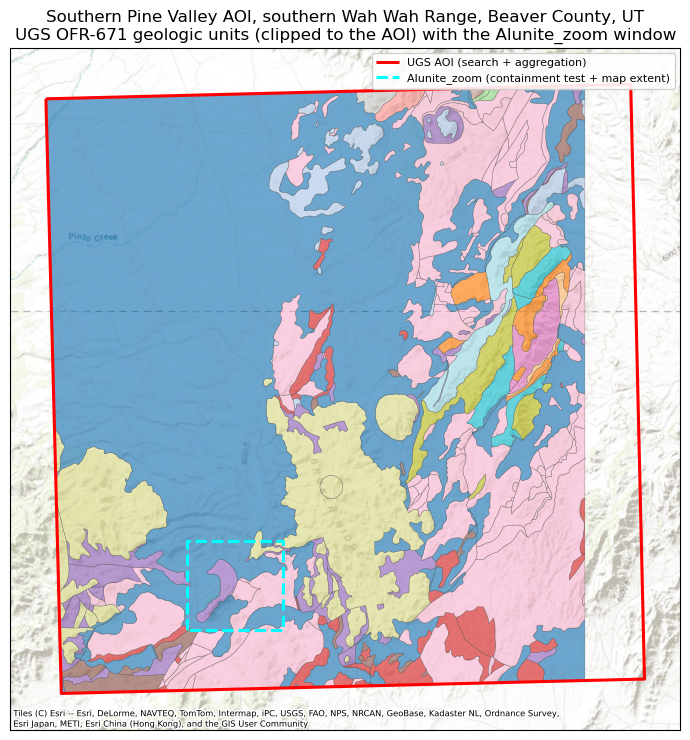


Blawn Formation units in the AOI (host of the lithophile critical-metal suite):
UnitSymbol                             UnitName
       Tbr   Rhyolite member of Blawn Formation
       Tbm Mafic flow member of Blawn Formation


In [10]:
# --- One study-area map: OFR-671 geology + AOI + Alunite_zoom over a topographic basemap --------
# contextily serves web-mercator (EPSG:3857) tiles, so every vector layer is reprojected to match.
roi_3857 = roi_gdf.to_crs(epsg=3857)
zoom_3857 = gpd.GeoSeries([zoom_poly], crs=4326).to_crs(epsg=3857)

# The UGS geologic-unit polygons for the Southern Pine Valley area, clipped to the AOI so the map
# shows which rock units the spectral targets sit in before any data is loaded.
GEO_DIR = DATA_DIR / "ofr-671"
geo_units_fp = GEO_DIR / "OFR-671DM_SouthernPineValleyArea_Shapefiles" / \
    "SouthernPineValleyArea_GeologicUnits.shp"

geo = gpd.read_file(geo_units_fp).to_crs(epsg=4326)
geo_aoi = gpd.clip(geo, roi_gdf)                      # keep only units within the AOI
geo_aoi_3857 = geo_aoi.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8.5, 7.5))
# Color by stratigraphic grouping (categorical). tab20 gives enough distinct hues for the units.
geo_aoi_3857.plot(ax=ax, column="Grouping", categorical=True, legend=True, cmap="tab20",
                  alpha=0.65, edgecolor="0.3", linewidth=0.3,
                  legend_kwds={"fontsize": 6, "loc": "center left",
                               "bbox_to_anchor": (1.0, 0.5), "title": "Geologic grouping"})
roi_3857.boundary.plot(ax=ax, color="red", linewidth=2.2, zorder=5, label="UGS AOI (search + aggregation)")
zoom_3857.boundary.plot(ax=ax, color="cyan", linewidth=2.2, linestyle="--", zorder=6,
                        label="Alunite_zoom (containment test + map extent)")

# Frame to the full AOI extent plus a ~6% margin, so the whole polygon is visible with context.
minx, miny, maxx, maxy = roi_3857.total_bounds
padx, pady = 0.06 * (maxx - minx), 0.06 * (maxy - miny)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
try:
    # Esri.WorldTopoMap = named cartographic tiles (place names, roads, contours + hillshade).
    cx.add_basemap(ax, source=cx.providers.Esri.WorldTopoMap, crs=geo_aoi_3857.crs, attribution_size=6)
except Exception as e:
    print("basemap tiles unavailable (offline?) - plotting vector layers only:", e)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.set_title("Southern Pine Valley AOI, southern Wah Wah Range, Beaver County, UT\n"
             "UGS OFR-671 geologic units (clipped to the AOI) with the Alunite_zoom window")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(FIG_DIR / "01_study_area.png", dpi=130, bbox_inches="tight")
plt.show()

# --- Unit legend / description table (from the OFR-671 attribute table) ------------------------
# The published attribute table is Latin-1 encoded (not UTF-8). We list the units actually present
# in the AOI, joined to their names/ages, so the map above is readable and the Blawn Formation
# rhyolites that host the critical-metal system stand out.
geo_attr = pd.read_csv(GEO_DIR / "OFR-671DM_SouthernPineValley_GeologicUnit_AttributeTable.csv",
                       encoding="latin-1")
units_present = sorted(geo_aoi["UnitSymbol"].dropna().unique())
# Sort stratigraphically by the table's Rank (youngest->oldest), then show the readable columns.
tbl = (geo_attr[geo_attr["UnitSymbol"].isin(units_present)]
       .sort_values("Rank" if "Rank" in geo_attr.columns else "UnitSymbol")
       [["UnitSymbol", "UnitName", "Age", "Grouping"]]
       .reset_index(drop=True))
#print(f"Geologic units present in the AOI: {len(units_present)}")
#print(tbl.to_string(index=False))
blawn = tbl[tbl["Grouping"].str.contains("Blawn", case=False, na=False)]
if len(blawn):
    print("\nBlawn Formation units in the AOI (host of the lithophile critical-metal suite):")
    print(blawn[["UnitSymbol", "UnitName"]].to_string(index=False))

---
# 2. Assemble a multi-date EMIT L2B_MIN stack

| Product | short_name / concept-id |
|---------|-------------------------|
| EMIT L2B Mineralogy | `EMITL2BMIN` · `C2408034484-LPCLOUD` · DOI 10.5067/EMIT/EMITL2BMIN.001 |
| EMIT L2B Mineralogy Uncertainty | `EMITL2BMINUNCERT` (bundled in the same granule) |
| EMIT L2A Mask | `EMITL2ARFL` granule asset (per-pixel cloud flags) |

### How L2B_MIN works

EMIT L2B_MIN is produced by the Tetracorder expert system (USGS), which matches each pixel's
continuum-removed reflectance against a library of mineral spectra. Each pixel gets up to two
identifications:

- Group 1: the ~1 µm (electronic / Fe) region.
- Group 2: the 2.0–2.5 µm region, where the Al-OH sulfates and phyllosilicates
  (alunite, muscovite, kaolinite, pyrophyllite, dickite) live.

The product stores, per pixel, `group_{1,2}_mineral_id` (an integer index into a spectral library)
and `group_{1,2}_band_depth`; the companion MINUNCERT file carries `group_{1,2}_fit`. We will
translate the integer IDs into mineral names, apply quality gates, and reduce each scene to a
single categorical indicator raster, then stack those rasters in time.

The L2B_MIN granule bundles both the MIN and MINUNCERT files, so we read those asset URLs
straight from the granule metadata rather than hand-building any URL.

In [11]:
# --- Search NASA CMR for EMIT L2B mineralogy granules over the ROI -----------------------------
# EMIT L2BMIN ("Estimated Mineral Identification and Band Depth") is the spaceborne mineral-mapping
# product we build section 3 on. We query by the collection's CMR concept-id (a stable handle for
# "this exact product + version") and the ROI polygon, so CMR returns only granules that overlap our
# study area. count=500 is just a safe upper bound on how many results to page back.
EMIT_L2BMIN_CID = "C2408034484-LPCLOUD"

emit_results = earthaccess.search_data(
    concept_id=EMIT_L2BMIN_CID,     # EMIT L2B mineralogy, LP DAAC cloud collection
    polygon=roi_coords,             # CCW ROI vertices from the cell above (CMR wants CCW)
    count=500,                      # max granules to return (we expect far fewer)
)
# Each result is a granule spanning some date/time. The next cells screen these by cloud cover and
# by footprint completeness to assemble the multi-date stack that section 4 aggregates.
print(f"EMIT L2BMIN granules over ROI: {len(emit_results)}")

EMIT L2BMIN granules over ROI: 52


### 2.1 Screen the candidates: cloud cover, and containment of the `Alunite_zoom` window

Two filters are applied to the candidate granules, each for a different reason.

Cloud cover. EMIT granules do carry a per-granule cloud value: CMR reports it as the standard
UMM `CloudCover` field (a scene-average percent, 0–100), which `earthaccess` exposes at
`result["umm"]["CloudCover"]`. Clouds and their shadows corrupt retrieved surface reflectance and
therefore every L2B_MIN identification built on it, so we drop any scene above `CLOUD_MAX`. This
is a coarse first pass: it rejects mostly-cloudy granules but says nothing about which pixels
are cloudy, so section 3 additionally applies the per-pixel L2A cloud mask.

Containment of the `Alunite_zoom` window. This filter matters more than it first appears. A
CMR polygon search returns every granule that touches the AOI, including ones that clip only a
corner. If a partial scene enters the stack, the pixels it never saw would be indistinguishable
from pixels it saw and found nothing in. That single ambiguity would invalidate the persistence
product: a pixel observed 10 times and called alunite 8 times, and a pixel observed twice and
called alunite twice, would both read as "alunite" unless observation counts are tracked
separately.

The containment test is applied to the `Alunite_zoom` window, not to the full AOI. That is a
deliberate choice about where completeness is required. The zoom window is where the alunite
exposure sits, where the UGS samples were collected, and where every conclusion in sections 4 and 5
is drawn; a scene that covers it end to end is usable even if it clips the far corner of the 23 km
AOI. Requiring full-AOI containment instead would discard otherwise sound scenes for coverage the
analysis never interrogates, and with an opportunistic ISS revisit pattern that is a costly
requirement to impose.

The consequence is that the stack is not uniformly complete across the whole AOI, so the
denominator matters. Section 4 carries a per-pixel valid-observation count and normalises by it,
which handles both the AOI margins left partly covered by this looser screen and the residual edge
effects that containment alone would miss in any case (a granule's CMR footprint polygon is a
coarse quadrilateral, so it can claim ground the sensor never actually imaged).

In [12]:
# --- Build a candidate table from granule metadata only (no downloads yet) ----------------------
CLOUD_MAX = 25.0     # percent scene-average cloud; above this the scene is dropped outright

def granule_name(r):
    return r["umm"]["GranuleUR"]

def granule_cloud(r):
    """Scene-average cloud percent from the UMM CloudCover field (nan if absent)."""
    try:
        return float(r["umm"]["CloudCover"])
    except (KeyError, TypeError, ValueError):
        return np.nan

def granule_date(r):
    return r["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"][:10]

def granule_footprint(r):
    """Granule spatial footprint as a shapely polygon (GPolygon preferred, bbox fallback)."""
    geo = r["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]
    if "GPolygons" in geo:
        ring = geo["GPolygons"][0]["Boundary"]["Points"]
        return shape({"type": "Polygon",
                      "coordinates": [[(p["Longitude"], p["Latitude"]) for p in ring]]})
    b = geo["BoundingRectangles"][0]
    return box(b["WestBoundingCoordinate"], b["SouthBoundingCoordinate"],
               b["EastBoundingCoordinate"], b["NorthBoundingCoordinate"])

cand = pd.DataFrame([{
    "granule": granule_name(r),
    "date": granule_date(r),
    "cloud_pct": granule_cloud(r),
    # Completeness is required over the Alunite_zoom window, not the whole AOI: that is the ground
    # every conclusion below rests on. See the discussion above.
    "covers_zoom": granule_footprint(r).contains(zoom_poly),
} for r in emit_results])
cand["result"] = list(emit_results)          # keep the earthaccess object for the asset URLs
cand["year"] = cand["date"].str[:4]
# Calendar month of each acquisition (Jan, Feb, ...), reported below to show how the eligible
# scenes are distributed through the year.
cand["month"] = pd.to_datetime(cand["date"]).dt.strftime("%b")

n_total = len(cand)
n_covers = int(cand["covers_zoom"].sum())
n_clear = int((cand["cloud_pct"] <= CLOUD_MAX).sum())

eligible = (cand[cand["covers_zoom"] & (cand["cloud_pct"] <= CLOUD_MAX)]
            .sort_values("cloud_pct")
            .reset_index(drop=True))

print(f"granules returned by CMR        : {n_total}")
print(f"  ... containing Alunite_zoom   : {n_covers}   (the rest only clip it)")
print(f"  ... at or below {CLOUD_MAX:.0f}% cloud     : {n_clear}")
print(f"  ... eligible (both conditions): {len(eligible)}")
if len(eligible):
    print(f"\ncloud range of eligible scenes  : {eligible['cloud_pct'].min():.0f}"
          f"-{eligible['cloud_pct'].max():.0f}%")
    print(f"date range                      : {eligible['date'].min()} .. {eligible['date'].max()}")
    print(f"distinct years / months         : {eligible['year'].nunique()} / "
          f"{eligible['month'].nunique()}")
    print("\neligible scenes (clearest first):")
    print(eligible[["date", "cloud_pct", "granule"]].to_string(index=False))

granules returned by CMR        : 52
  ... containing Alunite_zoom   : 20   (the rest only clip it)
  ... at or below 25% cloud     : 23
  ... eligible (both conditions): 9

cloud range of eligible scenes  : 4-12%
date range                      : 2023-04-20 .. 2026-04-15
distinct years / months         : 3 / 5

eligible scenes (clearest first):
      date  cloud_pct                                      granule
2025-06-20        4.0 EMIT_L2B_MIN_001_20250620T182509_2517112_014
2025-08-01        4.0 EMIT_L2B_MIN_001_20250801T184807_2521312_012
2023-10-16        6.0 EMIT_L2B_MIN_001_20231016T210319_2328914_012
2023-04-20        7.0 EMIT_L2B_MIN_001_20230420T200006_2311013_012
2023-06-27        8.0 EMIT_L2B_MIN_001_20230627T170626_2317811_012
2023-10-09       11.0 EMIT_L2B_MIN_001_20231009T165914_2328211_009
2026-04-15       11.0 EMIT_L2B_MIN_001_20260415T200247_2610513_018
2023-04-24       12.0 EMIT_L2B_MIN_001_20230424T182248_2311412_013
2026-01-29       12.0 EMIT_L2B_MIN_001_20260129T1

### 2.2 Choose the stack size

`N_SCENES` is the one knob that trades runtime for aggregate quality. More scenes means a smoother
persistence estimate and a more trustworthy mode, at three files (~140 MB) per scene.

Note what we are not doing: we rank by cloud, not by date, and we make no attempt to spread
the selection evenly through time. EMIT's revisit is opportunistic, so the stack is an
irregularly-sampled multi-date composite, not a time series. It therefore supports the question
"is this mineral persistently detected here?" but not "is this mineral changing over time?" The term
temporal can obscure that distinction, so it is stated explicitly here. The date spread is printed
below to show how uneven the sampling is.

In [13]:
N_SCENES = 12    # Stack size. Each additional scene costs roughly 140 MB of download and
                 # constrains the aggregate a little better; 6 to 12 is a reasonable range. Scenes
                 # already present in data/ are reused rather than downloaded again.

picks = eligible.head(N_SCENES).reset_index(drop=True)
if len(picks) < N_SCENES:
    print(f"note: only {len(picks)} scenes are eligible, so the stack is smaller than N_SCENES="
          f"{N_SCENES}. The aggregation code below is N-agnostic.")

print(f"selected {len(picks)} scenes, cloud {picks['cloud_pct'].min():.0f}"
      f"-{picks['cloud_pct'].max():.0f}%\n")
print(picks[["date", "cloud_pct", "granule"]].to_string(index=False))

# Report how the selected scenes are distributed across years and months.
_by_year = picks.groupby("year").size()
print("\nscenes per year:", _by_year.to_dict())
print("months represented:", sorted(picks['month'].unique()))
print("\nThis stack is a multi-date composite rather than a time series: the scenes follow")
print("EMIT's opportunistic revisit pattern and were ranked by cloud cover, not by date.")

note: only 9 scenes are eligible, so the stack is smaller than N_SCENES=12. The aggregation code below is N-agnostic.
selected 9 scenes, cloud 4-12%

      date  cloud_pct                                      granule
2025-06-20        4.0 EMIT_L2B_MIN_001_20250620T182509_2517112_014
2025-08-01        4.0 EMIT_L2B_MIN_001_20250801T184807_2521312_012
2023-10-16        6.0 EMIT_L2B_MIN_001_20231016T210319_2328914_012
2023-04-20        7.0 EMIT_L2B_MIN_001_20230420T200006_2311013_012
2023-06-27        8.0 EMIT_L2B_MIN_001_20230627T170626_2317811_012
2023-10-09       11.0 EMIT_L2B_MIN_001_20231009T165914_2328211_009
2026-04-15       11.0 EMIT_L2B_MIN_001_20260415T200247_2610513_018
2023-04-24       12.0 EMIT_L2B_MIN_001_20230424T182248_2311412_013
2026-01-29       12.0 EMIT_L2B_MIN_001_20260129T191031_2602912_012

scenes per year: {'2023': 5, '2025': 2, '2026': 2}
months represented: ['Apr', 'Aug', 'Jan', 'Jun', 'Oct']

This stack is a multi-date composite rather than a time series: the sce

---
# 3. Classify every scene identically

For the stack to mean anything, every scene must go through the same pipeline. This
section builds that pipeline once as a function, then applies it in a loop.

Per scene:

1. resolve the MIN / MINUNCERT asset URLs from the granule metadata, plus the matching L2A MASK
   granule (matched on the orbit/scene suffix, e.g. `..._2223014_011`);
2. download with caching and an integrity check;
3. build the per-pixel cloud mask from the L2A MASK flag bands and apply it while still in
   sensor space;
4. spatially subset to the AOI, then orthorectify (cheaper in that order, since we only warp the
   pixels we keep);
5. apply the quality gates and reduce to one categorical indicator class per pixel;
6. also return a boolean observed raster, which supplies the per-pixel denominator used in
   section 4.

In [14]:
# --- Cached, integrity-checked download --------------------------------------------------------
def _is_readable_netcdf(path):
    """True if `path` opens as HDF5/netCDF-4 (catches truncated/partial downloads cheaply)."""
    try:
        with h5py.File(path, "r"):
            return True
    except Exception:
        return False


def cached_download(url, subdir=DATA_DIR, quiet=False):
    """Download `url` to `subdir` unless a complete copy is already present; return local path.

    A download interrupted partway (e.g. the kernel killed under memory pressure) leaves a
    truncated netCDF. Trusting size > 0 alone makes every later run reuse that corrupt file and
    fail on open, so we verify the cached file actually opens and re-download it if it does not."""
    dst = Path(subdir) / url.split("/")[-1]
    if dst.exists() and dst.stat().st_size > 0:
        if _is_readable_netcdf(dst):
            if not quiet:
                print("    cached:", dst.name)
            return dst
        print("    cached file is truncated/corrupt, re-downloading:", dst.name)
        dst.unlink()
    elif not quiet:
        print("    downloading:", dst.name)
    earthaccess.download([url], local_path=str(subdir))
    if not _is_readable_netcdf(dst):
        raise OSError(f"download did not produce a readable netCDF: {dst.name} "
                      f"({dst.stat().st_size if dst.exists() else 0} bytes) - re-run to retry.")
    return dst


def data_urls(result):
    """Asset URLs straight from the granule metadata, rather than hand-built."""
    try:
        return result.data_links()
    except Exception:
        return [u["URL"] for u in result["umm"]["RelatedUrls"] if u.get("Type") == "GET DATA"]


# The L2A MASK lives in a different collection (EMITL2ARFL), so index it once by scene suffix.
print("indexing the L2A collection so each L2B scene can find its matching cloud mask ...")
rfl_results = earthaccess.search_data(short_name="EMITL2ARFL", polygon=roi_coords, count=500)
rfl_by_suffix = {}
for r in rfl_results:
    nm = granule_name(r)
    rfl_by_suffix["_".join(nm.split("_")[-2:])] = r      # e.g. '2223014_011' -> granule
print(f"  {len(rfl_by_suffix)} L2A granules indexed over the AOI")


def scene_asset_urls(result):
    """(min_url, minunc_url, mask_url) for one L2B_MIN granule; mask_url may be None."""
    assets = data_urls(result)
    min_url = [u for u in assets if "_L2B_MIN_" in u and u.endswith(".nc")][0]
    minunc_url = [u for u in assets if "_L2B_MINUNCERT_" in u and u.endswith(".nc")][0]
    suffix = "_".join(granule_name(result).split("_")[-2:])
    mask_url = None
    if suffix in rfl_by_suffix:
        masks = [u for u in data_urls(rfl_by_suffix[suffix])
                 if "_L2A_MASK_" in u and u.endswith(".nc")]
        mask_url = masks[0] if masks else None
    return min_url, minunc_url, mask_url

indexing the L2A collection so each L2B scene can find its matching cloud mask ...
  52 L2A granules indexed over the AOI


### 3.1 Mineral-ID → name lookup, and the indicator classes

L2B_MIN stores integer IDs, not names. The IDs index into a spectral library carried as coordinate
variables on the file itself, so the first scene is opened once to recover that lookup table and
list what the library contains. ID 0 means "no identification" and is not stored as a library row,
so it is prepended explicitly.

The class definitions themselves come from the EMIT mineral grouping matrix
(`data/mineral_grouping_matrix_20230503.csv`), which maps every library entry to a mineral group;
the cell below collapses those groups into 5 alteration-indicator classes that track the
lithocap zoning. Note the many alunite variants the library carries: K versus Na end-members,
synthetic alunites at different temperatures, ammonio-alunite, and alunite mixed with dickite,
kaolinite, pyrophyllite or muscovite. Collapsing these into one "Alunite" class suits the question
posed here (is there alunite, not which alunite), but it discards composition information, so
the class boundaries warrant review.

In [15]:
# --- Open the first selected scene just to recover the library lookup --------------------------
_probe_min_url, _, _ = scene_asset_urls(picks.loc[0, "result"])
_probe_fp = cached_download(_probe_min_url)
_probe = et.emit_xarray(str(_probe_fp), ortho=False)

# Every coordinate defined along the `mineral_name` dimension is a library column.
min_df = pd.DataFrame(
    {v: _probe[v].values for v in _probe.coords if "mineral_name" in _probe[v].dims})
zero_row = {c: (0 if c == "index" else ("No_Match" if c == "mineral_name" else np.nan))
            for c in min_df.columns}
min_df.loc[-1] = zero_row                             # id 0 = No_Match, not stored in the library
min_df = min_df.sort_index().reset_index(drop=True)   # move it to row 0, renumber cleanly
del _probe
#print("library entries (including No_Match):", len(min_df))
print(min_df.head())

    downloading: EMIT_L2B_MIN_001_20250620T182509_2517112_014.nc


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

   index  record                              mineral_name  \
0    0.0     NaN                                  No_Match   
1    1.0  6858.0          Plastic_Tarp GDS339 Green W1R1Fa   
2    2.0   744.0        Hematite.02+Quartz.98 GDS76 W1R1Ha   
3    3.0   882.0  Goethite WS222 <250um MedGrn W1R1H_ AREF   
4    4.0  5736.0         Goethite0.02+Quartz GDS240 W1R1Ba   

                                                           url  group  library  
0                                                          NaN    NaN      NaN  
1  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Plast...    1.0  splib06  
2  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Hemat...    1.0  sprlb06  
3  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Goeth...    1.0  sprlb06  
4  https://crustal.usgs.gov/speclab/data/HTMLmetadata/Goeth...    1.0  splib06  


In [16]:
# --- Group the raw library minerals into the 5 alteration indicator classes ---------------------
# The spectral library has many named entries (e.g. several alunite compositions, muscovite/illite
# variants). For a readable map we collapse them into 5 alteration-indicator classes that track the
# lithocap zoning: Alunite + Pyrophyllite (advanced argillic / acidic core), White mica + Kaolinite +
# Dickite (argillic / sericitic). We match on substrings of the library `Name` (case-insensitive).
matrix = pd.read_csv(DATA_DIR / "mineral_grouping_matrix_20230503.csv")

# Reference patterns (documentation of what each class captures; the actual matching is in
# classify_name below, which needs ordered checks to resolve compound names correctly).
INDICATOR_PATTERNS = {
    "Alunite":      r"alunite",
    "White mica":   r"muscovite|illite|sericite",
    "Kaolinite":    r"kaolin",
    "Dickite":      r"dickite",
    "Pyrophyllite": r"pyrophyl",
}

def classify_name(name):
    """Map one library mineral name to an indicator class, or None if it is not an indicator."""
    n = str(name).lower()
    # Order matters: some library names are compound (e.g. "muscovite+pyrophyllite"). We check the
    # more diagnostic / less ambiguous minerals first so a mixture is assigned to the right class.
    if "alunite" in n:       return "Alunite"
    if "dickite" in n:       return "Dickite"
    if "kaolin" in n:        return "Kaolinite"
    if "pyrophyl" in n and "musc" not in n: return "Pyrophyllite"   # pure pyrophyllite, not musc+pyr mixes
    if any(k in n for k in ("muscovite", "illite", "sericite")): return "White mica"
    return None

matrix["indicator"] = matrix["Name"].apply(classify_name)   # tag every library row with its class
indicators = matrix.dropna(subset=["indicator"])            # keep only the indicator minerals
print("Indicator library entries by class:")
print(indicators["indicator"].value_counts())
print("\nAlunite variants detected in the library:")
for nm in indicators[indicators.indicator == "Alunite"]["Name"]:
    print("  -", nm)

Indicator library entries by class:
indicator
Alunite         20
White mica      11
Kaolinite        4
Pyrophyllite     3
Dickite          1
Name: count, dtype: int64

Alunite variants detected in the library:
  - Alunite GDS97 K Syn (150C) W2R4Na
  - Alunite GDS96 K Syn (250C) W2R4Na
  - Alunite RES-2 K Syn (450C) W2R4Na
  - Alunite GDS95 Na Syn (150C) W2R4Na
  - Alunite RES-4 Na Syn (300C) W2R4Na
  - Alunite RES-3 Na Syn (450C) W2R4Na
  - Alunite GDS82 Na82 W1R1Bb
  - Alunite+Dickite MV99-6-26b W1R1Fc
  - Alunite GDS83 Na63 W1R1Bb
  - Alunite RES-9 Summitv (400C) W2R4Nb
  - Alunite GDS84 Na03 W2R4Na
  - Alunite RES10 NA56% Syn 450C W2R4Na
  - Alunite RES12 NA78% Syn 450C W2R4NaIS
  - Alunite0.35K+.65Na CU91-217H W2R4Nb
  - Alunite0.73K+.27Na CU91-217D W2R4Na
  - Alunite0.66K+.34Na CU91-217A W2R4Nb
  - Alunite+Pyrophyl SD1093A W1R1Bb
  - Alunite0.5+Kaol_KGa-1 AMX3 W1R1Bb
  - Alunite.5+MuscCU91-250A AMX4 W1R1Ba
  - Alunite_NH4+Jaro NMNH145596A W1R1Bb


In [17]:
# --- Fix the class integers, draw order and colors (shared by every figure below) --------------
# INDICATOR_ORDER sets the class integer each indicator gets (Alunite=1 ... White mica=5) and the
# acidic -> near-neutral reading order of every colorbar. Class 0 = no confident detection.
INDICATOR_ORDER = ["Alunite", "Pyrophyllite", "Kaolinite", "Dickite", "White mica"]
INDICATOR_COLORS = {
    "Alunite": "#d7191c", "Pyrophyllite": "#fdae61", "Kaolinite": "#ffffbf",
    "Dickite": "#abd9e9", "White mica": "#2c7bb6",
}
ALUNITE_CLASS = INDICATOR_ORDER.index("Alunite") + 1     # == 1; the class this notebook is about

ind_cmap = mcolors.ListedColormap([INDICATOR_COLORS[i] for i in INDICATOR_ORDER])
# Bin edges on the half-integers (0.5, 1.5, 2.5, ...) place each integer class at the centre of
# its own colour band, so colorbar ticks land on the class labels rather than between them.
ind_norm = mcolors.BoundaryNorm(np.arange(0.5, len(INDICATOR_ORDER) + 1.5), ind_cmap.N)

# Map every indicator library Index -> its class integer, for fast membership tests per pixel.
id_to_class = {}
for _, row in indicators.iterrows():
    id_to_class[int(row["Index"])] = INDICATOR_ORDER.index(row["indicator"]) + 1
class_ids = {ci: [i for i, c in id_to_class.items() if c == ci]
             for ci in range(1, len(INDICATOR_ORDER) + 1)}

print("library IDs per indicator class:")
for ci, ind in enumerate(INDICATOR_ORDER, start=1):
    print(f"  {ci}  {ind:13s} {len(class_ids[ci]):3d} library entries")

library IDs per indicator class:
  1  Alunite        20 library entries
  2  Pyrophyllite    3 library entries
  3  Kaolinite       4 library entries
  4  Dickite         1 library entries
  5  White mica     11 library entries


### 3.2 The per-scene classifier

Two quality gates, following the `mined-lands` acid-mine-drainage workflow, with the stored fit
rescaled as described below:

- band depth ≥ `BAND_DEPTH_MIN`: the absorption feature is deep enough to be real rather than
  noise;
- fit ≥ `FIT_MIN`: the library spectrum actually matched the pixel well.

> Storage scaling of `group_*_fit`. The L2B fit (a correlation coefficient) is stored scaled
> by 1/2, so it must be multiplied by 2 before thresholding. Omitted, a `fit >= 0.4` gate
> silently becomes `fit >= 0.8`, which removes most true detections and leaves the map empty.

Where two indicators are both detected in a pixel (one in group 1, one in group 2), we keep
whichever has the deeper band depth. And alongside the class raster we return `observed`:
`True` where the scene actually delivered usable data for that pixel: inside the orthorectified
swath, not cloud-flagged, not fill. Section 4 depends on that raster.

The band depth of the winning identification is returned as a third raster. Section 4.2 averages it
across the scenes that called a pixel alunite, which gives a measure of how strong the alunite
absorption typically is at that pixel, independent of how often it was detected there.

In [18]:
BAND_DEPTH_MIN = 0.02   # minimum group band depth to trust a detection
FIT_MIN = 0.40          # minimum library-fit quality (after undoing the 1/2 storage scaling)
CLOUD_FLAG_BANDS = [0, 1, 3]   # L2A MASK flag bands 0 Cloud, 1 Cirrus, 3 Spacecraft. Band 4 is
                               # the dilated-cloud buffer: stricter, and not used here.
USE_PIXEL_CLOUD_MASK = True    # set False to skip the ~60 MB MASK download per scene


def classify_scene(result, verbose=True):
    """Reduce one EMIT L2B_MIN granule to (class_da, observed_da, depth_da) on its own ortho grid.

    class_da   : int16, 0 = no confident indicator, 1..5 = INDICATOR_ORDER class
    observed_da: bool, True where the scene delivered usable (non-fill, non-cloud) data
    depth_da   : float32, band depth of the identification recorded in class_da, NaN where none
    """
    gid = granule_name(result)
    min_url, minunc_url, mask_url = scene_asset_urls(result)
    fp_min = cached_download(min_url, quiet=not verbose)
    fp_minunc = cached_download(minunc_url, quiet=not verbose)

    # 1. Per-pixel cloud mask, built in sensor space so emit_xarray can apply it pre-ortho.
    qmask = None
    if USE_PIXEL_CLOUD_MASK and mask_url is not None:
        fp_mask = cached_download(mask_url, quiet=not verbose)
        qmask = et.quality_mask(str(fp_mask), CLOUD_FLAG_BANDS)   # 1 = reject
    elif USE_PIXEL_CLOUD_MASK and verbose:
        print("    no matching L2A MASK granule - proceeding without a per-pixel cloud mask")

    # 2. Open (masked) -> subset to AOI -> orthorectify. The order matters: subsetting in
    #    sensor space means ortho_xr only warps the handful of pixels we actually keep.
    ds = et.emit_xarray(str(fp_min), ortho=False, qmask=qmask)
    ds = et.spatial_subset(ds, roi_gdf)
    ds = et.ortho_xr(ds)

    unc = et.emit_xarray(str(fp_minunc), ortho=False, qmask=qmask)
    unc = et.spatial_subset(unc, roi_gdf)
    unc = et.ortho_xr(unc)

    ny, nx = ds["group_1_band_depth"].shape
    cls = np.zeros((ny, nx), dtype="int16")
    best_bd = np.zeros((ny, nx), dtype="float32")
    observed = np.zeros((ny, nx), dtype=bool)

    for group in (1, 2):
        ids = ds[f"group_{group}_mineral_id"].values
        bd = ds[f"group_{group}_band_depth"].values
        fit = unc[f"group_{group}_fit"].values * 2.0      # undo the 1/2 storage scaling
        # "Observed" = this pixel carries real (non-fill) values. ortho_xr fills outside the
        # swath with -9999, and the cloud mask above wrote -9999 into rejected pixels, so a
        # finite non-negative band depth is our test for "the sensor gave us something here".
        observed |= np.isfinite(bd) & (bd > -1.0)
        ok = (bd >= BAND_DEPTH_MIN) & (fit >= FIT_MIN) & np.isfinite(bd)
        # Where a pixel qualifies in more than one group or class, keep the strongest detection:
        # `bd > best_bd` lets a later candidate overwrite an earlier one only if its band depth is
        # larger, so `cls` ends up holding the single deepest indicator per pixel.
        for ci, lib_ids in class_ids.items():
            m = ok & np.isin(ids, lib_ids) & (bd > best_bd)
            cls[m] = ci
            best_bd[m] = bd[m]

    # The band depth of the winning identification is kept rather than discarded. Section 4.2
    # averages it over the scenes that called a pixel alunite, so it has to survive the per-scene
    # reduction. Pixels with no confident identification carry NaN instead of 0, which keeps them
    # out of that average rather than pulling it toward zero.
    depth = np.where(cls > 0, best_bd, np.nan).astype("float32")

    coords = {"latitude": ds["latitude"], "longitude": ds["longitude"]}
    dims = ("latitude", "longitude")
    return (xr.DataArray(cls, coords=coords, dims=dims, name="indicator_class"),
            xr.DataArray(observed, coords=coords, dims=dims, name="observed"),
            xr.DataArray(depth, coords=coords, dims=dims, name="band_depth"))

### 3.3 Run the classifier over every selected scene

The loop is defensive by design. A granule can fail for reasons unrelated to this analysis: a
footprint that claims the AOI but clips to an empty tile, a transient download error, an asset
missing from the metadata. We catch per scene, report, and carry on with whatever succeeded,
because losing one scene from a 12-scene stack is a minor degradation while a raised exception
halfway through would cost the entire run.

In [19]:
# Classify every selected scene, keeping the successes. Each iteration returns three aligned
# rasters: the indicator class per pixel, a boolean "this pixel was validly observed" layer that
# becomes the per-pixel denominator in section 4.2, and the band depth of the identification the
# class label came from.
series = []          # list of (date, cloud_pct, granule, class_da, observed_da, depth_da)
for _, row in picks.iterrows():
    print(f"[{row['date']}  {row['cloud_pct']:5.1f}% cloud]  {row['granule']}")
    try:
        cls_da, obs_da, bd_da = classify_scene(row["result"])
        # A granule footprint can claim the AOI and still clip to nothing once subset. That is
        # not an error, so it is reported and skipped rather than raised.
        if cls_da.size == 0 or cls_da.latitude.size == 0 or cls_da.longitude.size == 0:
            print("    -> skipped: clipped to an empty tile over the AOI")
            continue
        # Per-scene tallies, printed so that a scene contributing almost nothing is visible here
        # rather than only in the aggregate: valid observations, pixels carrying any indicator
        # class (class 0 means "no indicator"), and pixels called alunite specifically.
        n_obs = int(obs_da.values.sum())
        n_det = int((cls_da.values > 0).sum())
        n_alun = int((cls_da.values == ALUNITE_CLASS).sum())
        print(f"    -> {cls_da.shape[0]}x{cls_da.shape[1]} px | observed {n_obs} | "
              f"indicator {n_det} | alunite {n_alun}")
        series.append((row["date"], row["cloud_pct"], row["granule"], cls_da, obs_da, bd_da))
    except Exception as e:
        print(f"    -> skipped: {type(e).__name__}: {e}")

print(f"\n{len(series)} of {len(picks)} scenes classified successfully")
if not series:
    raise SystemExit("no scenes classified - cannot aggregate. Check Earthdata auth and network.")

[2025-06-20    4.0% cloud]  EMIT_L2B_MIN_001_20250620T182509_2517112_014
    cached: EMIT_L2B_MIN_001_20250620T182509_2517112_014.nc
    downloading: EMIT_L2B_MINUNCERT_001_20250620T182509_2517112_014.nc


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

    downloading: EMIT_L2A_MASK_001_20250620T182509_2517112_014.nc


...

    downloading: EMIT_L2A_MASK_001_20260129T191031_2602912_012.nc


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Flags used: ['Cloud flag' 'Cirrus flag' 'Spacecraft Flag']
    -> 389x486 px | observed 180386 | indicator 3033 | alunite 1796

9 of 9 scenes classified successfully


### 3.4 Look at the scenes before aggregating them

This panel is a key diagnostic, because it displays scene-to-scene instability directly,
which is the motivation for aggregating in the first place. The alunite core (red) should recur in
approximately the same place while the surrounding classes flicker, and at least one scene will
typically look unlike the others. That outlier scene is what an aggregate guards against: had it
been selected as the single scene for interpretation, it would have supported a spurious
exploration target.

The figure is capped at eight panels so that it remains legible at figure size and translates
directly to a slide. Every scene in the stack still contributes to the aggregation in section 4;
the cap governs only what is displayed here.

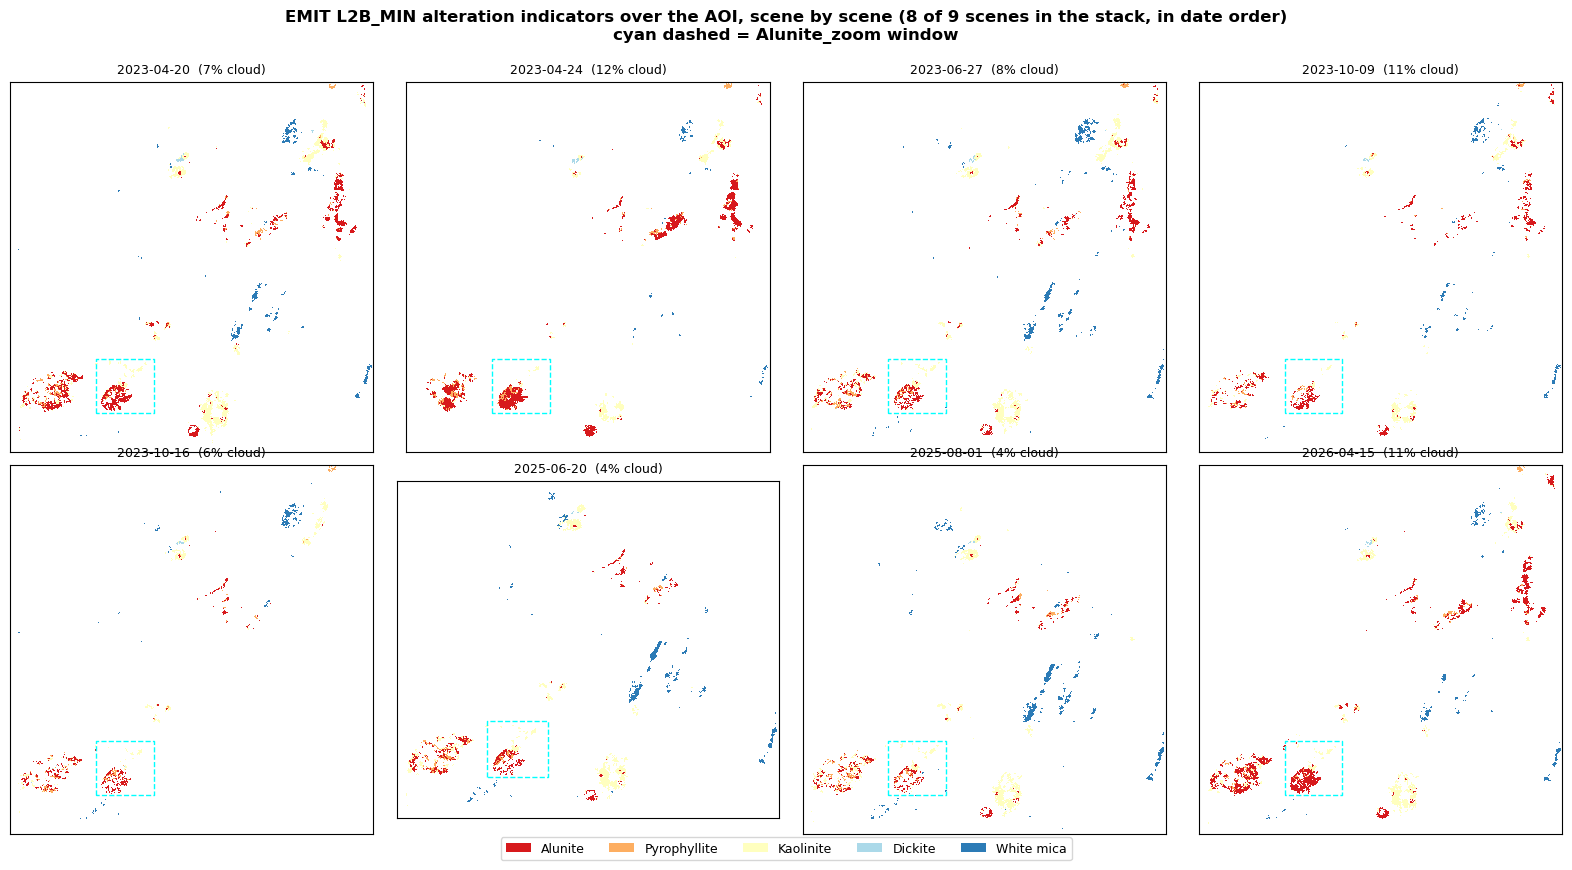

In [20]:
# One small map per scene, so that scene-to-scene variability is visible before any aggregation is
# applied. At most PANEL_MAX scenes are drawn: the panel is a qualitative diagnostic rather than a
# quantitative one, and a fixed four-by-two grid stays legible at figure size and when the figure is
# reused outside the notebook. The scenes shown are the clearest ones, since the stack is already
# ranked by cloud cover, and they are ordered by date so the panel reads chronologically.
PANEL_MAX = 8
n_stack = len(series)
panel = sorted(series[:PANEL_MAX], key=lambda s: s[0])
n = len(panel)
ncol = min(4, n)
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 4.2 * nrow), squeeze=False)

for ax, (date, cc, gid, cls_da, obs_da, bd_da) in zip(axes.ravel(), panel):
    # Class 0 means "no indicator identified". Converting it to NaN leaves those pixels
    # unpainted instead of drawing them as a colour.
    arr = np.where(cls_da.values > 0, cls_da.values, np.nan)
    # pcolormesh rather than imshow: every scene has its own slightly different lat/lon grid,
    # and pcolormesh takes those coordinate arrays directly instead of assuming one extent.
    ax.pcolormesh(cls_da.longitude.values, cls_da.latitude.values, arr,
                  cmap=ind_cmap, norm=ind_norm, shading="auto", zorder=2)
    gpd.GeoSeries([zoom_poly], crs=4326).boundary.plot(
        ax=ax, color="cyan", linewidth=1.0, linestyle="--", zorder=3)
    ax.set_title(f"{date}  ({cc:.0f}% cloud)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.ravel()[n:]:
    ax.set_axis_off()

# Matplotlib has no artist to describe a hand-built categorical overlay, so the legend is built
# from proxy artists: one coloured rectangle per class, drawn nowhere, used only as a key.
handles = [plt.Rectangle((0, 0), 1, 1, fc=INDICATOR_COLORS[i]) for i in INDICATOR_ORDER]
fig.legend(handles, INDICATOR_ORDER, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"EMIT L2B_MIN alteration indicators over the AOI, scene by scene "
             f"({n} of {n_stack} scenes in the stack, in date order)\n"
             "cyan dashed = Alunite_zoom window", y=1.0, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_scene_panel.png", dpi=120, bbox_inches="tight")
plt.show()

---
# 4. Aggregate the stack in time

Each selected scene has been classified into a
categorical raster on its own grid, with its own valid-observation footprint. Those rasters reduce
to four products:

| Product | Meaning |
|---|---|
| `n_obs` | how many scenes validly observed this pixel |
| `mode1`, `mode2` | the 1st and 2nd most common indicator class across those observations |
| `alun_persist` | fraction of valid observations in which this pixel was called alunite |
| `alun_mean_bd` | mean band depth of those alunite identifications, where alunite is `mode1` |

The last two are the exploration products: how often the alunite identification recurs at a pixel,
and how deep the absorption is when it does. Section 5 maps the mean band depth beneath the ground
geochemistry.

### 4.1 Put every scene on a common grid with nearest neighbour, never interpolation

EMIT's orthorectified products all use the same ~0.00054° pixel size, but each scene's grid
origin is wherever that overpass happened to land. So two scenes over the same ground have
lat/lon coordinates offset by some fraction of a pixel, and `numpy` will not stack them.

The fix is to pick one scene's grid as the target and snap the others onto it with
`reindex(..., method="nearest", tolerance=half_a_pixel)`.

> Why `nearest` and not interpolation. These are categorical class labels. Class 4 is not
> "more" than class 3, and averaging class 3 and class 5 into class 4 would invent a mineral that
> was never detected. Any interpolating resample, whether bilinear, cubic, or even a simple mean, is
> mathematically valid and geologically meaningless here. `nearest` with a half-pixel tolerance
> moves each label at most half a pixel (~30 m, below EMIT's own geolocation uncertainty) and
> refuses to guess beyond that, returning NaN instead.
>
> Why the tolerance matters. Without it, `reindex` would pull a label from a pixel
> kilometres away at the edge of a scene, silently smearing detections outward. The tolerance is
> what keeps the nearest-neighbour snap defensible.

All three per-scene rasters are snapped the same way, but each takes a different fill. A class that
did not survive the snap becomes 0 ("no detection"), an observation that did not survive becomes
`False` ("not observed"), which is the distinction the next cell depends on, and a band depth that
did not survive becomes NaN, so it is excluded from the averaging rather than counted as zero
depth.

In [21]:
# --- Choose a target grid: the scene covering the most ground over the AOI ----------------------
# Every scene arrives on its own ortho grid. Use the largest of them as the common target grid,
# so the stack is snapped onto the scene that covers the most of the AOI.
_sizes = [(cls.latitude.size * cls.longitude.size, i)
          for i, (_, _, _, cls, _, _) in enumerate(series)]
target_i = max(_sizes)[1]
target = series[target_i][3]
HALF_PIX = float(abs(target.longitude.values[1] - target.longitude.values[0])) / 2

print(f"target grid: scene {series[target_i][0]} ({series[target_i][2]})")
# 111320 m per degree of longitude at the equator, scaled by cos(38.1 deg) for this latitude.
# The ortho grid is square in degrees, so its ground footprint differs by axis: 111 130 m per
# degree of latitude, against 111 320 m x cos(38.1 deg) per degree of longitude at this latitude.
# The nominal 60 m EMIT pixel is the north-south figure.
_pix_ns = HALF_PIX * 2 * 111130
_pix_ew = HALF_PIX * 2 * 111320 * np.cos(np.radians(38.1))
print(f"  {target.latitude.size} x {target.longitude.size} px, "
      f"pixel {HALF_PIX * 2:.6f} deg (~{_pix_ns:.0f} m north-south, ~{_pix_ew:.0f} m east-west)")
print(f"  snap tolerance = half a pixel = {HALF_PIX:.6f} deg (~{_pix_ns / 2:.0f} m north-south)")


def on_target_grid(da, fill):
    """Snap `da` onto the target grid: nearest neighbour, at most half a pixel, else `fill`."""
    return (da.reindex(latitude=target.latitude, longitude=target.longitude,
                       method="nearest", tolerance=HALF_PIX)
              .fillna(fill))


cls_stack = np.stack([on_target_grid(cls, 0).values
                      for _, _, _, cls, _, _ in series]).astype("int16")
obs_stack = np.stack([on_target_grid(obs.astype("int8"), 0).values
                      for _, _, _, _, obs, _ in series]).astype(bool)
# The band depths keep NaN as their fill, so a pixel that carried no identification in a given
# scene contributes nothing to that pixel's mean depth instead of contributing a zero.
bd_stack = np.stack([on_target_grid(bd, np.nan).values
                     for _, _, _, _, _, bd in series]).astype("float32")
lat = target.latitude.values
lon = target.longitude.values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

print(f"\nstacked: {cls_stack.shape}  (scenes, lat, lon)")
print(f"pixels observed at least once : {int((obs_stack.any(axis=0)).sum()):,}")
print(f"pixels observed by all {len(series)} scenes: {int((obs_stack.all(axis=0)).sum()):,}")

target grid: scene 2026-01-29 (EMIT_L2B_MIN_001_20260129T191031_2602912_012)
  389 x 486 px, pixel 0.000542 deg (~60 m north-south, ~48 m east-west)
  snap tolerance = half a pixel = 0.000271 deg (~30 m north-south)

stacked: (9, 389, 486)  (scenes, lat, lon)
pixels observed at least once : 180,386
pixels observed by all 9 scenes: 58,337


### 4.2 The aggregation kernel

`top2_modes` follows the same aggregation kernel used in the `mined-lands` acid-mine-drainage
workflow. It builds a per-class vote cube, one count layer per
indicator class, then reads the 1st and 2nd modal class off it with `argmax`, zeroing the winner
before the second pass.

Two behaviours to account for when interpreting its output:

1. Ties break to the lowest class integer. `classes` is sorted ascending and `np.argmax`
   returns the first maximum, so a pixel called alunite in 3 scenes and kaolinite in 3 scenes
   reports as alunite (class 1). Since we ordered `INDICATOR_ORDER` acidic-first, ties are biased
   toward the acidic end of the alteration sequence, which is convenient for finding lithocaps, but it is a
   bias, not a measurement.
2. There is no minimum-vote threshold. A class detected in one observation still
   becomes that pixel's `mode1`. That is why `agree1`, the winner's vote count, must be carried
   alongside and reported: on a modal-class map alone, a detection made in a single observation is
   indistinguishable from one made in every observation. The cell below reports the median and
   maximum of `agree1` for precisely that reason.

The cell then reduces the same stack to two quantitative rasters. `alun_persist` divides each
pixel's alunite votes by its valid observations, and `alun_mean_bd` averages the band depth of those
alunite identifications. One reports how reliably alunite is identified at a pixel, the other how
deep the absorption is where it is identified, and neither stands in for the other: a shallow
feature recovered in every scene and a deep feature recovered in a third of them are different
geological propositions. Band depth responds to abundance, grain size and the fraction of the pixel
that is exposed rock, so it is a measure of spectral strength rather than of mineral percentage.

In [22]:
def top2_modes(stack, classes):
    """Per-pixel 1st & 2nd most common class across the scene axis, ignoring 0.

    Returns (mode1, mode2, agree1) where agree1 is the winning class's vote count - the confidence
    attached to mode1, without which a 1-of-12 detection is indistinguishable from 12-of-12."""
    classes = np.asarray(sorted(classes), dtype="int16")
    # The vote cube: one layer per class, each holding the number of scenes in which that class
    # was assigned to that pixel. Shape (n_classes, ny, nx).
    votes = np.stack([(stack == c).sum(axis=0) for c in classes]).astype("int16")

    def _winner(v):
        idx = v.argmax(axis=0)                       # ties -> lowest class index (see 4.2 note 1)
        won = classes[idx]
        return np.where(v.max(axis=0) > 0, won, 0).astype("int16"), idx

    mode1, idx1 = _winner(votes)
    agree1 = votes.max(axis=0).astype("int16")
    votes2 = votes.copy()
    # Zero the winning class at every pixel so that the same argmax returns second place.
    # np.indices supplies the row and column grids that pair with idx1, which turns this into one
    # advanced-indexing assignment over the whole raster instead of a Python loop.
    li, lj = np.indices(idx1.shape)
    votes2[idx1, li, lj] = 0
    mode2, _ = _winner(votes2)
    return mode1, mode2, agree1


ALL_CLASSES = list(range(1, len(INDICATOR_ORDER) + 1))
mode1, mode2, agree1 = top2_modes(cls_stack, ALL_CLASSES)

# The denominator: how many scenes validly observed each pixel.
n_obs = obs_stack.sum(axis=0).astype("int16")

# --- Alunite persistence, the notebook's primary quantitative product -------------------------
# The count of alunite calls is normalised by each pixel's own valid observations rather than by
# the number of scenes in the stack, and the distinction is the whole argument. A pixel that eight
# of twelve scenes never imaged, and that the four remaining scenes all called alunite, is a
# 4-of-4 persistent detection, not a marginal 4-of-12 one. Dividing by the scene count would
# fabricate low persistence wherever coverage is incomplete: at scene edges, and at every pixel a
# cloud mask ever touched. Because cloud is spatially structured, so is that artefact.
MIN_OBS = 3     # a fraction computed from fewer valid observations than this is not reportable

valid = n_obs >= MIN_OBS
alun_count = (cls_stack == ALUNITE_CLASS).sum(axis=0).astype("int16")
# Two guards on the division. np.maximum(n_obs, 1) avoids dividing by zero at pixels EMIT never
# validly observed, and np.where then discards those results as NaN, so thin coverage is left
# blank in every figure rather than plotted as a zero that would read as an absence of alunite.
# The errstate context only keeps numpy from warning about values that are discarded regardless.
with np.errstate(invalid="ignore", divide="ignore"):
    alun_persist = np.where(valid, alun_count / np.maximum(n_obs, 1), np.nan)

# --- Mean band depth of the alunite identifications -------------------------------------------
# Persistence answers how often alunite is identified at a pixel. This answers how strong the
# 2.17 micron absorption is when it is. The denominator is the number of scenes that called the
# pixel alunite, not the number that observed it, so the two products stay independent: a pixel
# detected in 3 of 12 scenes and one detected in 12 of 12 are on the same footing here, and only
# the depth of those detections separates them. The raster is reported only where alunite is the
# modal class, which is the ground section 5 interprets.
alun_mode = mode1 == ALUNITE_CLASS
_bd_alun = np.where(cls_stack == ALUNITE_CLASS, bd_stack, np.nan)
with np.errstate(invalid="ignore", divide="ignore"):
    alun_mean_bd = np.where(alun_mode & valid,
                            np.nansum(_bd_alun, axis=0) / np.maximum(alun_count, 1), np.nan)

print("aggregate class counts (pixels):")
for ci, ind in enumerate(INDICATOR_ORDER, start=1):
    print(f"  {ind:13s}  mode1 {int((mode1 == ci).sum()):7,d}   "
          f"mode2 {int((mode2 == ci).sum()):7,d}")
print(f"  {'no detection':13s}  mode1 {int((mode1 == 0).sum()):7,d}")
print(f"\nn_obs: min {int(n_obs.min())}, median {int(np.median(n_obs))}, max {int(n_obs.max())}")
print(f"agree1 where mode1 > 0: median {int(np.median(agree1[mode1 > 0])) if (mode1 > 0).any() else 0}"
      f", max {int(agree1.max())}")

print(f"\npixels with n_obs >= {MIN_OBS}: {int(valid.sum()):,} of {valid.size:,} "
      f"({100 * valid.sum() / valid.size:.1f}%)")
print(f"pixels ever called alunite     : {int((alun_count > 0).sum()):,}")
print(f"pixels alunite in >=50% of obs : {int((np.nan_to_num(alun_persist) >= 0.5).sum()):,}")
print(f"pixels alunite in all obs      : {int((np.nan_to_num(alun_persist) >= 0.999).sum()):,}")

_bdv = alun_mean_bd[np.isfinite(alun_mean_bd)]
print(f"\npixels with alunite as mode1   : {int(_bdv.size):,}")
if _bdv.size:
    print(f"mean alunite band depth there  : median {np.median(_bdv):.3f}, "
          f"5th-95th percentile {np.percentile(_bdv, 5):.3f} to {np.percentile(_bdv, 95):.3f}, "
          f"max {_bdv.max():.3f}")

aggregate class counts (pixels):
  Alunite        mode1   3,864   mode2     513
  Pyrophyllite   mode1     561   mode2     831
  Kaolinite      mode1   2,727   mode2     431
  Dickite        mode1      54   mode2      27
  White mica     mode1   1,717   mode2      10
  no detection   mode1 180,131

n_obs: min 0, median 8, max 9
agree1 where mode1 > 0: median 3, max 9

pixels with n_obs >= 3: 180,386 of 189,054 (95.4%)
pixels ever called alunite     : 4,381
pixels alunite in >=50% of obs : 1,583
pixels alunite in all obs      : 116

pixels with alunite as mode1   : 3,864
mean alunite band depth there  : median 0.082, 5th-95th percentile 0.046 to 0.165, max 0.270


### 4.3 The modal-mineral maps

`mode1` is the aggregate alteration map, the class each pixel is most often called. `mode2`
is the runner-up, and it is more informative than it sounds: where `mode2` is a coherent map rather
than noise, it records real sub-pixel mixing. At 60 m an EMIT pixel routinely straddles an
alteration boundary, so alunite-then-kaolinite or alunite-then-white-mica pairings trace the
zoning gradient, the acidic core grading outward into its halo, rather than indecision.

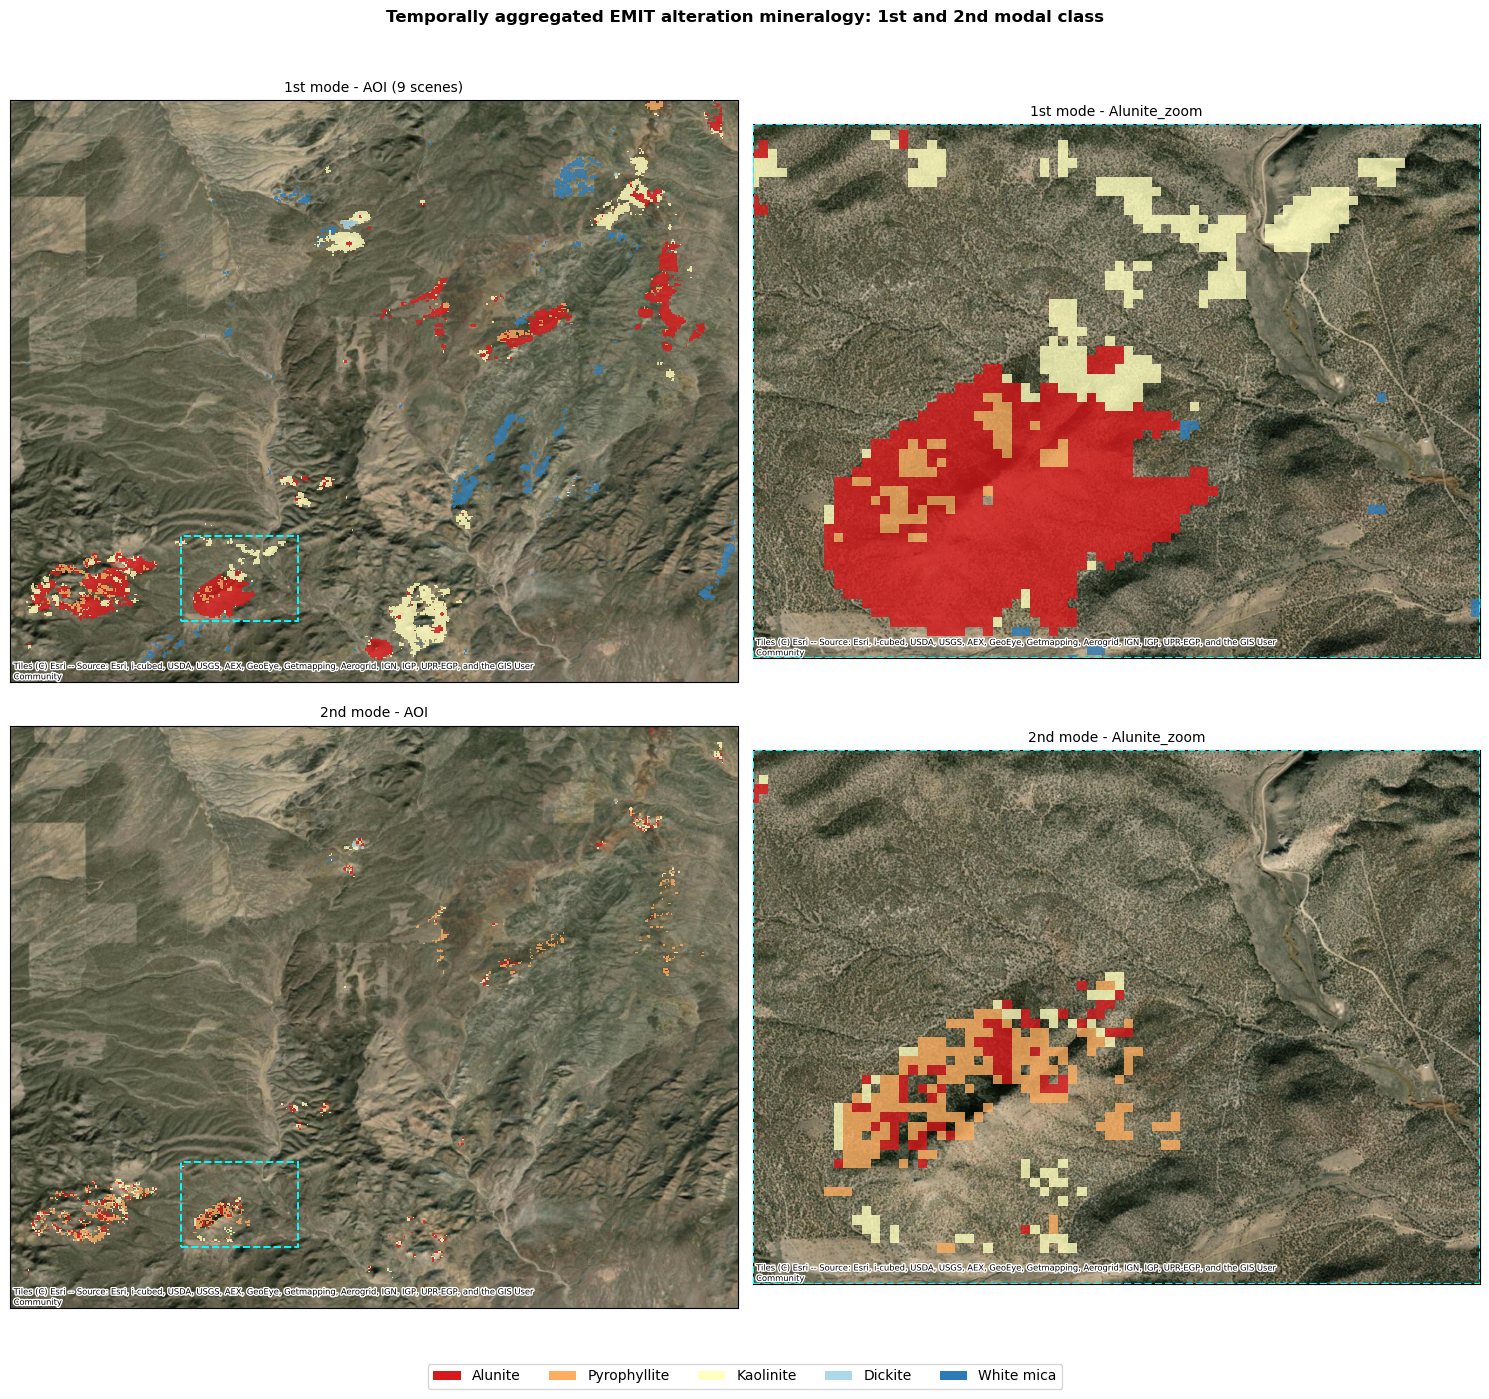

In [23]:
def plot_classes(arr, title, ax, framed=True):
    """Draw a categorical indicator raster over satellite imagery (0 = transparent)."""
    # The overlay is built explicitly as RGBA rather than through a colormap so that alpha can
    # carry the "no indicator" state: every pixel starts fully transparent (alpha 0) and only
    # classified pixels are filled, at 80% opacity, letting the imagery show through elsewhere.
    rgba = np.zeros(arr.shape + (4,), dtype=float)
    for ci, ind in enumerate(INDICATOR_ORDER, start=1):
        rgba[arr == ci] = mcolors.to_rgba(INDICATOR_COLORS[ind], alpha=0.80)
    ax.imshow(rgba, extent=extent, origin="upper", interpolation="nearest", zorder=3)
    # Outline the Alunite_zoom window, which orients the AOI-wide panels against the framed ones.
    ax.add_patch(plt.Rectangle((zoom_xlim[0], zoom_ylim[0]),
                               zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
                               fill=False, edgecolor="cyan", linewidth=1.4, linestyle="--",
                               zorder=4))
    if framed:
        ax.set_xlim(*zoom_xlim); ax.set_ylim(*zoom_ylim)
    try:
        # Basemap tiles are fetched over the network, so a failure here must not abort the
        # figure: the overlay is the data, the imagery is context.
        cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, crs="EPSG:4326",
                       attribution_size=6, zorder=1)
    except Exception as e:
        print("basemap tiles unavailable (offline?):", e)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(2, 2, figsize=(15, 14))
plot_classes(mode1, f"1st mode - AOI ({len(series)} scenes)", axes[0, 0], framed=False)
plot_classes(mode1, "1st mode - Alunite_zoom", axes[0, 1])
plot_classes(mode2, "2nd mode - AOI", axes[1, 0], framed=False)
plot_classes(mode2, "2nd mode - Alunite_zoom", axes[1, 1])
handles = [plt.Rectangle((0, 0), 1, 1, fc=INDICATOR_COLORS[i]) for i in INDICATOR_ORDER]
fig.legend(handles, INDICATOR_ORDER, loc="lower center", ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, 0.005))
fig.suptitle("Temporally aggregated EMIT alteration mineralogy: 1st and 2nd modal class",
             fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.savefig(FIG_DIR / "01_modal_classes.png", dpi=130, bbox_inches="tight")
plt.show()

---
# 5. Compare the aggregate with UGS surface geochemistry

Everything so far is internal to the remote-sensing data: we have shown that EMIT calls alunite in
the same places repeatedly, which demonstrates consistency, not correctness. A pipeline can be
consistently wrong. This section brings in an independent measurement.

### The geochemical reference data and how the alunite estimate is derived

The UGS collected 138 surface samples across the AOI with full major-oxide and trace-element
chemistry. Two of the columns are independent stoichiometric estimates of alunite abundance, built
on the two elements that alunite `KAl3(SO4)2(OH)6` must contain:

- `pct_alunite_from_K2O`: alunite is normally the only significant potassium-bearing phase
  in an advanced-argillic assemblage, because kaolinite, dickite and pyrophyllite are all K-free
  Al-silicates. Where that assumption holds, K₂O is close to a stoichiometric proxy for alunite.
- `pct_alunite_from_SO3`: the same calculation via sulfate, from total sulfur.

Neither column is sufficient on its own, because each has its own failure mode. Potassium also
resides in feldspar and sericite, so the K₂O route reports alunite in fresh or weakly altered
rhyolite. Sulfur also resides in jarosite, gypsum and sulfides, so the SO₃ route can report alunite
where the sulfate present is not aluminous. A sample is therefore treated as alunite-bearing only
where both columns report alunite, and section 5.1 applies that requirement explicitly.

Among the corroborated samples, `pct_alunite_from_K2O` is the quantity mapped. That choice comes
from the data owners rather than from the table itself: UGS X-ray powder diffraction (XRPD)
analysis of these samples found that, when both columns are present, the K₂O estimate tracks the
measured alunite percentage more closely than the SO₃ estimate does.

### What this comparison can and cannot establish

The claim this comparison supports is narrower than it may first appear. These are hand samples
(centimetres) compared against 60 m pixels, collected on different dates, and the "ground"
value is itself a stoichiometric
inference from bulk chemistry rather than a measured mineral abundance. Spatial coincidence
between the two therefore demonstrates cross-method coherence, two independent techniques
finding the same pattern, rather than pixel-level validation. The exercise does not validate the
EMIT product in a formal sense, and the reasons why are as instructive as the agreement itself.

### 5.1 Load and screen the UGS geochemistry

The UGS dataset holds 138 surface samples with WGS84 coordinates, two estimated alunite
percentages, and a suite of whole-rock element concentrations, including the lithophile critical
metals Be, Li and U. Two spatial screens are applied before anything is compared. The samples are
restricted to the `Alunite_zoom` window, because that is the ground the aggregate raster is
interpreted over and section 5.2 displays; samples elsewhere in the AOI are dropped here rather
than carried forward as a second set of counts.

Two properties of the laboratory table have to be handled before either alunite column can be used
as a number. Results above the calibrated range are stored as strings (`>30.0`), and results below
the detection limit are stored as negative sentinel values (`-0.1`). Both are read with
`errors="coerce"`, which turns them into `NaN` rather than letting a string column silently defeat
the arithmetic or a negative percentage enter a correlation.

The compositional screen follows from the mineral formula: alunite contains both potassium and
sulfate, so a sample counts as alunite-bearing only where both estimates report alunite. That
divides the samples in the window into two groups: those corroborated by both routes, and all
others. `ALUN_MIN_PCT` sets how much each route has to report.

In [25]:
# --- 5.1 Load the UGS geochemistry -------------------------------------------------------------
# A plain sample table with WGS84 Latitude/Longitude (plus UTM zone-12N we do not need). Note the
# UTF-8 byte-order-mark on the first column name, which must be stripped or lookups by name fail.
geo_csv = DATA_DIR / "geochem" / "alunite_geochem_subset_2026_09_09.csv"
gchem = pd.read_csv(geo_csv)
gchem.columns = [c.strip().lstrip("﻿") for c in gchem.columns]
gchem_gdf = gpd.GeoDataFrame(
    gchem, geometry=gpd.points_from_xy(gchem["Longitude"], gchem["Latitude"]), crs="EPSG:4326")

ALUN_COL = "pct_alunite_from_K2O"   # the quantity mapped, per the UGS XRPD comparison
ALUN_SO3 = "pct_alunite_from_SO3"   # the corroborating estimate, via sulfate
ALUN_MIN_PCT = 3.0                  # percent alunite each route must report to count as present

# Restrict the samples to the Alunite_zoom window before anything else. The window is the ground the
# aggregate raster is interpreted over and the only extent section 5.2 displays, so samples outside
# it would contribute counts and colour-scale limits that no figure or conclusion ever uses.
in_zoom = ((gchem_gdf.geometry.x >= zoom_xlim[0]) & (gchem_gdf.geometry.x <= zoom_xlim[1]) &
           (gchem_gdf.geometry.y >= zoom_ylim[0]) & (gchem_gdf.geometry.y <= zoom_ylim[1]))
print(f"UGS samples in the table: {len(gchem_gdf)}  |  inside Alunite_zoom: {int(in_zoom.sum())}")
gchem_gdf = gchem_gdf.loc[in_zoom].reset_index(drop=True)

# Coerce both estimates to numbers. ">30.0" (above calibrated range) and negative values (below
# detection limit) become NaN, which fails every comparison below - the behaviour we want, since
# neither is a usable alunite percentage. The numeric versions replace the raw columns on the
# GeoDataFrame so that every plot and statistic downstream reads the same screened values.
gchem_gdf[ALUN_COL] = pd.to_numeric(gchem_gdf[ALUN_COL], errors="coerce").where(lambda s: s >= 0)
gchem_gdf[ALUN_SO3] = pd.to_numeric(gchem_gdf[ALUN_SO3], errors="coerce").where(lambda s: s >= 0)
k2o, so3 = gchem_gdf[ALUN_COL], gchem_gdf[ALUN_SO3]

# Alunite carries both potassium and sulfate, so accept a sample as alunite-bearing only where both
# routes report it. That gives two groups, which is all the comparison needs: samples corroborated
# by both estimates, and every other sample. The complement is retained rather than dropped, because
# section 5.2 needs the negatives - a persistence map is only useful if the ground is also negative
# where the map is dark.
gchem_gdf["alun_both"] = (k2o >= ALUN_MIN_PCT) & (so3 >= ALUN_MIN_PCT)
gchem_gdf["alun_other"] = ~gchem_gdf["alun_both"]

print(f"sample extent in the window: "
      f"lon {gchem_gdf.geometry.x.min():.4f}..{gchem_gdf.geometry.x.max():.4f}  |  "
      f"lat {gchem_gdf.geometry.y.min():.4f}..{gchem_gdf.geometry.y.max():.4f}")

print(f"\nsample groups in the Alunite_zoom window at ALUN_MIN_PCT = {ALUN_MIN_PCT:g}%")
for _label, _mask in [("both routes report alunite (accepted)", gchem_gdf["alun_both"]),
                      ("all other samples                    ", gchem_gdf["alun_other"])]:
    print(f"  {_label}  {int(_mask.sum()):>3}")

print(f"\n{ALUN_COL} over the accepted samples (%):")
print(k2o[gchem_gdf["alun_both"]].describe().round(2).to_string())

UGS samples in the table: 138  |  inside Alunite_zoom: 104
sample extent in the window: lon -113.6667..-113.6419  |  lat 38.0447..38.0655

sample groups in the Alunite_zoom window at ALUN_MIN_PCT = 3%
  both routes report alunite (accepted)   76
  all other samples                       28

pct_alunite_from_K2O over the accepted samples (%):
count    76.00
mean     21.79
std      11.37
min       3.00
25%      14.15
50%      20.15
75%      28.12
max      54.40


### 5.2 Map: ground samples over the mean alunite band depth

The backdrop is the temporal aggregate from section 4.2, not a single scene: at every pixel
whose modal class is alunite, the mean band depth of the alunite identifications that produced that
mode. Deeper values mark ground where the alunite absorption is consistently strong, which is what
distinguishes a well developed acid-sulfate cap from a marginal occurrence at the edge of the
detection limit. The samples are drawn in the two groups established in section 5.1:

- Filled circles are the accepted samples, coloured by `pct_alunite_from_K2O` on a sequential
  colormap (it is a quantity, not a category), stretched to the 98th percentile of those samples so
  that a single very high assay cannot compress the rest of the range into one shade.
- Crosses are all other samples. They carry no colour, because an alunite percentage that the
  second estimate does not corroborate is not a value worth placing on a colour scale. They matter
  as much as the filled circles: the map is only useful if the ground is also negative where EMIT
  aggregated no alunite.

Read this map for coincidence of pattern rather than point-by-point agreement: the question is
whether the high-alunite samples fall on ground where EMIT recovers a deep alunite absorption, and
samples without corroborated alunite fall off it.

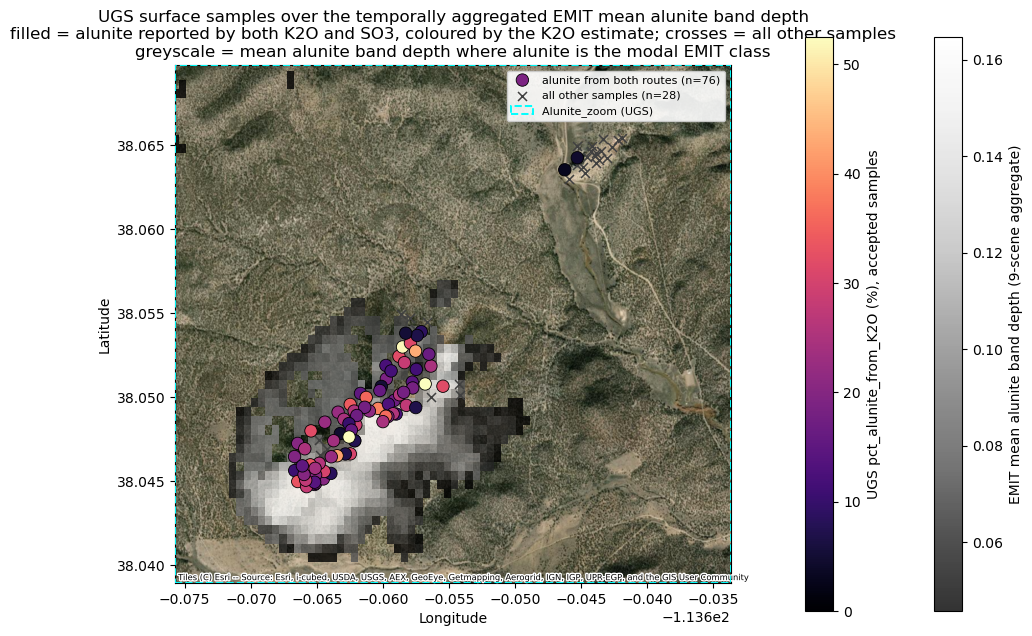

In [26]:
fig, ax = plt.subplots(figsize=(10, 8.5))

# Two quantities and two colour scales: the greyscale EMIT mean alunite band depth underneath,
# magma-coloured accepted sample assays on top. alun_mean_bd is already NaN wherever alunite is not
# the modal class, so the basemap imagery shows through there rather than a uniform dark wash.
#
# The greyscale is stretched between the 5th and 95th percentiles of the mapped pixels. Unlike a
# persistence fraction, band depth has no natural 0 to 1 range, and limits chosen by eye would
# either saturate the deep core or flatten the weaker margins of the cap.
_bd_seen = alun_mean_bd[np.isfinite(alun_mean_bd)]
_bd_lo, _bd_hi = ((float(np.percentile(_bd_seen, 5)), float(np.percentile(_bd_seen, 95)))
                  if _bd_seen.size else (0.0, 1.0))
if _bd_hi <= _bd_lo:
    _bd_hi = _bd_lo + 1e-3          # keeps the colour scale valid if every mapped pixel is equal
im = ax.imshow(alun_mean_bd, extent=extent, origin="upper", cmap="Greys_r",
               vmin=_bd_lo, vmax=_bd_hi, alpha=0.80, interpolation="nearest", zorder=2)
roi_gdf.boundary.plot(ax=ax, color="k", linewidth=1.0, zorder=3)

# The two sample groups from section 5.1, drawn as two separate scatter calls so that each can carry
# its own symbol and its own legend entry.
_acc = gchem_gdf[gchem_gdf["alun_both"]]
_oth = gchem_gdf[gchem_gdf["alun_other"]]

# Stretch the point colours to the 98th percentile of the accepted samples, so a few very high
# assays do not compress the rest of the range into one shade.
_vmax = float(np.nanpercentile(_acc[ALUN_COL], 98))
sc = ax.scatter(_acc.geometry.x, _acc.geometry.y, c=_acc[ALUN_COL],
                cmap="magma", s=80, edgecolor="k", linewidth=0.6, zorder=7,
                vmin=0, vmax=_vmax,
                label=f"alunite from both routes (n={len(_acc)})")
ax.scatter(_oth.geometry.x, _oth.geometry.y, color="0.25", marker="x",
           s=42, linewidth=1.1, zorder=5, label=f"all other samples (n={len(_oth)})")

ax.add_patch(plt.Rectangle((zoom_xlim[0], zoom_ylim[0]),
                           zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
                           fill=False, edgecolor="cyan", linewidth=1.4, linestyle="--",
                           zorder=4, label="Alunite_zoom (UGS)"))
ax.set_xlim(*zoom_xlim); ax.set_ylim(*zoom_ylim)
try:
    cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, crs="EPSG:4326",
                   attribution_size=6, zorder=1)
except Exception as e:
    print("basemap tiles unavailable (offline?):", e)

cb1 = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cb1.set_label(f"EMIT mean alunite band depth ({len(series)}-scene aggregate)")
cb2 = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.10)
cb2.set_label("UGS pct_alunite_from_K2O (%), accepted samples")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.set_title("UGS surface samples over the temporally aggregated EMIT mean alunite band depth\n"
             "filled = alunite reported by both K2O and SO3, coloured by the K2O estimate; "
             "crosses = all other samples\n"
             "greyscale = mean alunite band depth where alunite is the modal EMIT class")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_geochem_over_band_depth.png", dpi=130, bbox_inches="tight")
plt.show()

---
# 6. Synthesis

### Summary of the workflow

We searched the EMIT archive over the UGS Southern Pine Valley AOI, kept only scenes that were
both clear (`CloudCover <= CLOUD_MAX`) and fully covering the `Alunite_zoom` window, and pushed
every one of them through an identical pipeline: per-pixel cloud masking from the L2A flags,
Tetracorder quality
gates on band depth and fit (remembering that fit is stored at 1/2 scale), and a reduction to five
alteration-indicator classes. We snapped the scenes onto a common grid with a half-pixel
nearest-neighbour tolerance, then aggregated in time to modal-class maps, an alunite-persistence
raster and the mean band depth of the alunite detections. Finally we restricted the UGS surface
samples to the `Alunite_zoom` window, screened those down to the samples whose alunite content is
reported by both the K₂O and the SO₃ route, and compared the aggregate against them.

### Four concepts to carry forward

1. Aggregation converts a categorical map into a quantitative one. A single L2B_MIN scene
supplies a label per pixel. A stack supplies a fraction, and a fraction can be thresholded,
ranked, compared against ground data, and reported together with the number of observations
standing behind it.

2. The denominator is a scientific choice, not a formatting detail. Dividing detection counts
by the number of scenes rather than by each pixel's valid observations manufactures
low-persistence artefacts at scene edges and wherever cloud masking removed observations. Because clouds are
spatially structured, so is the artefact: it looks like geology. Carrying an `observed` raster
alongside every class raster is what keeps "never detected" distinguishable from "never observed".

3. Reference data need screening before they can referee anything. Across the full published
table the two ground estimates of alunite agree with each other at only r ≈ 0.76, which invites the
conclusion that the ground data are too noisy to hold a remote product to account. That conclusion
would be wrong. Almost all of the disagreement comes from a dozen rhyolite samples in which
potassium sits in feldspar and sericite and sulfur is at or below detection: the K₂O route reports
tens of percent alunite in rocks that contain none. Requiring both routes to report alunite removes
those samples and raises the agreement between the routes to r ≈ 0.97. Deciding which samples are
admissible evidence is part of the analysis, not preparation for it.

4. Cross-method coherence is still not validation. The screened geochemistry is a real,
independent check, and spatial agreement with the aggregate rasters increases confidence in the
EMIT product. But hand samples compared against 60 m pixels, through a stoichiometric model of
alunite content and on different dates, sets a ceiling on the agreement that is achievable in
principle. Report the coincidence of pattern; do not report it as pixel-level accuracy.

### Geologic reading of the result

The persistent-alunite footprint marks the acidic core of the advanced-argillic lithocap developed
in the Miocene Blawn Formation rhyolites, the shallow expression of the acid-sulfate fluid
described by Lindsey & Osmonson (1978). The `mode2` map traces the outward zoning into
kaolinite/dickite and white mica, i.e. up the pH gradient. The lithophile critical-metal suite
(Be, Li, Mo, Sn, W, REE, U, F) resides in the evolved rhyolites and their near-neutral, fluorite-
bearing alteration rather than in the cap itself, so mapped alunite persistence is best used as a
vector to fertile ground, not as a metal-abundance proxy.

### Where to take this next

- Notebook 2 (`02_white_mica_absorption_centers.ipynb`) picks up the halo this notebook maps
  only as a class label. It moves to the Blawn Mountain / White Mountain districts and extracts
  the physical information in the Al-OH feature, its absorption center, which tracks
  white-mica composition and therefore fluid pH, comparing EMIT reflectance against
  higher-resolution AVIRIS-5 reflectance over the same ground.
- Tune the thresholds. `CLOUD_MAX`, `BAND_DEPTH_MIN`, `FIT_MIN` and `MIN_OBS` all trade
  sensitivity against reliability. Re-run with `N_SCENES = 5` and then `12` and watch how
  much the persistence raster stabilises; that convergence, or the lack of it, indicates whether
  the stack is deep enough.
- Add a seasonal split. With enough scenes, aggregate summer and winter separately. Persistent
  detections should be indifferent to season; anything that appears in only one is more likely
  vegetation phenology or illumination geometry than mineralogy.
- Try the same workflow elsewhere. Only the AOI file and the indicator class definitions are
  site-specific. The `mined-lands` repository applies the same aggregation to acid-mine-drainage
  minerals in the Iberian Pyrite Belt and at La Oroya, Peru.

### Data citations

- EMIT L2B Mineralogy: Green, R. et al. (2024). EMIT L2B Estimated Mineral Identification and
  Band Depth and Uncertainty 60 m V001. NASA LP DAAC. DOI 10.5067/EMIT/EMITL2BMIN.001
- EMIT L2A Reflectance & Mask: DOI 10.5067/EMIT/EMITL2ARFL.001
- Utah Geological Survey, Open-File Report 671 (geologic map) and the accompanying surface
  geochemical dataset.
- Lindsey, D.A. & Osmonson, L.M. (1978). Mineral potential of altered rocks near Blawn Mountain,
  Wah Wah Range, Utah. USGS Open-File Report 78-114.
- Barkoff, D.W. (2022). PhD dissertation, University of Nevada Las Vegas. DOI 10.34917/35777457
- Portela, B. et al. (2025). Ore Geology Reviews 182, 106673.